<a href="https://colab.research.google.com/github/Pranto210102/MY_ML_Work/blob/main/All_ML_Algo_Implementation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [50]:
# connect with GPU and check
import torch
torch.cuda.is_available()

True

# **Load Data**

In [51]:
# Access the dataset in my drive
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [52]:
# Read dataset
# all dataset take much more time to train, so I keep it simple for repetative run...
import pandas as pd
path1 = "/content/drive/MyDrive/Colab Dataset/DataSense: CIC IIoT dataset 2025/attack_samples_1sec.csv"
# path2 = "/content/drive/MyDrive/Colab Dataset/DataSense: CIC IIoT dataset 2025/attack_samples_2sec.csv"
# path3 = "/content/drive/MyDrive/Colab Dataset/DataSense: CIC IIoT dataset 2025/attack_samples_3sec.csv"
# path4 = "/content/drive/MyDrive/Colab Dataset/DataSense: CIC IIoT dataset 2025/attack_samples_4sec.csv"
# path5 = "/content/drive/MyDrive/Colab Dataset/DataSense: CIC IIoT dataset 2025/attack_samples_5sec.csv"
# path6 = "/content/drive/MyDrive/Colab Dataset/DataSense: CIC IIoT dataset 2025/attack_samples_6sec.csv"
# path7 = "/content/drive/MyDrive/Colab Dataset/DataSense: CIC IIoT dataset 2025/attack_samples_7sec.csv"
# path8 = "/content/drive/MyDrive/Colab Dataset/DataSense: CIC IIoT dataset 2025/attack_samples_8sec.csv"
# path9 = "/content/drive/MyDrive/Colab Dataset/DataSense: CIC IIoT dataset 2025/attack_samples_9sec.csv"
# path10 = "/content/drive/MyDrive/Colab Dataset/DataSense: CIC IIoT dataset 2025/attack_samples_10sec.csv"

path11 = "/content/drive/MyDrive/Colab Dataset/DataSense: CIC IIoT dataset 2025/benign_samples_1sec.csv"
# path12 = "/content/drive/MyDrive/Colab Dataset/DataSense: CIC IIoT dataset 2025/benign_samples_2sec.csv"
# path13 = "/content/drive/MyDrive/Colab Dataset/DataSense: CIC IIoT dataset 2025/benign_samples_3sec.csv"
# path14 = "/content/drive/MyDrive/Colab Dataset/DataSense: CIC IIoT dataset 2025/benign_samples_4sec.csv"
# path15 = "/content/drive/MyDrive/Colab Dataset/DataSense: CIC IIoT dataset 2025/benign_samples_5sec.csv"
# path16 = "/content/drive/MyDrive/Colab Dataset/DataSense: CIC IIoT dataset 2025/benign_samples_6sec.csv"
# path17 = "/content/drive/MyDrive/Colab Dataset/DataSense: CIC IIoT dataset 2025/benign_samples_7sec.csv"
# path18 = "/content/drive/MyDrive/Colab Dataset/DataSense: CIC IIoT dataset 2025/benign_samples_8sec.csv"
# path19 = "/content/drive/MyDrive/Colab Dataset/DataSense: CIC IIoT dataset 2025/benign_samples_9sec.csv"
# path20 = "/content/drive/MyDrive/Colab Dataset/DataSense: CIC IIoT dataset 2025/benign_samples_10sec.csv"

df1 = pd.read_csv(path1)
# df2 = pd.read_csv(path2)
# df3 = pd.read_csv(path3)
# df4 = pd.read_csv(path4)
# df5 = pd.read_csv(path5)
# df6 = pd.read_csv(path6)
# df7 = pd.read_csv(path7)
# df8 = pd.read_csv(path8)
# df9 = pd.read_csv(path9)
# df10 = pd.read_csv(path10)
df11 = pd.read_csv(path11)
# df12 = pd.read_csv(path12)
# df13 = pd.read_csv(path13)
# df14 = pd.read_csv(path14)
# df15 = pd.read_csv(path15)
# df16 = pd.read_csv(path16)
# df17 = pd.read_csv(path17)
# df18 = pd.read_csv(path18)
# df19 = pd.read_csv(path19)
# df20 = pd.read_csv(path20)

In [53]:
# marge and shuffle the data
df = pd.concat([df1,  df11])
df = df.sample(frac=1).reset_index(drop=True)

In [54]:
df.head(10)

,device_name,device_mac,label_full,label1,label2,label3,label4,timestamp,timestamp_start,timestamp_end,...,network_time-delta_min,network_time-delta_std_deviation,network_ttl_avg,network_ttl_max,network_ttl_min,network_ttl_std_deviation,network_window-size_avg,network_window-size_max,network_window-size_min,network_window-size_std_deviation
0,plug-rfid,d4:a6:51:1d:c0:ed,benign_whole-network3,benign,benign,benign,benign,2025-09-09T14:39:20.400000Z_2025-09-09T14:39:2...,2025-09-09T14:39:20.400000Z,2025-09-09T14:39:21.400000Z,...,0.000000e+00,0.000000,0.000000,0.0,0.0,0.000000,0.000000,0.0,0.0,0.000000
1,plug-proximity,d4:a6:51:20:0e:3f,benign_whole-network3,benign,benign,benign,benign,2025-09-09T15:04:04.400000Z_2025-09-09T15:04:0...,2025-09-09T15:04:04.400000Z,2025-09-09T15:04:05.400000Z,...,0.000000e+00,0.000000,0.000000,0.0,0.0,0.000000,0.000000,0.0,0.0,0.000000
2,light-sensor,8c:aa:b5:8a:a9:b4,benign_whole-network3,benign,benign,benign,benign,2025-09-09T14:25:28.400000Z_2025-09-09T14:25:2...,2025-09-09T14:25:28.400000Z,2025-09-09T14:25:29.400000Z,...,0.000000e+00,0.037299,159.500000,255.0,64.0,95.500000,34838.000000,64056.0,5620.0,29218.000000
3,soil-sensor,f0:08:d1:ce:cf:0c,benign_whole-network3,benign,benign,benign,benign,2025-09-09T14:57:33.400000Z_2025-09-09T14:57:3...,2025-09-09T14:57:33.400000Z,2025-09-09T14:57:34.400000Z,...,0.000000e+00,0.001791,159.500000,255.0,64.0,95.500000,34810.000000,64062.0,5558.0,29252.000000
4,dekco-camera,44:29:1e:5c:de:12,benign_whole-network3,benign,benign,benign,benign,2025-09-09T14:27:35.400000Z_2025-09-09T14:27:3...,2025-09-09T14:27:35.400000Z,2025-09-09T14:27:36.400000Z,...,0.000000e+00,0.000000,0.000000,0.0,0.0,0.000000,0.000000,0.0,0.0,0.000000
5,plug-motion,d4:a6:51:1d:74:3a,benign_whole-network3,benign,benign,benign,benign,2025-09-09T14:38:49.400000Z_2025-09-09T14:38:5...,2025-09-09T14:38:49.400000Z,2025-09-09T14:38:50.400000Z,...,0.000000e+00,0.000000,0.000000,0.0,0.0,0.000000,0.000000,0.0,0.0,0.000000
6,ap,30:de:4b:e2:13:4e,attack_recon_host-disc-tcp-ack-ping_ap,attack,recon,host-disc-tcp-ack-ping,recon_host-disc-tcp-ack-ping,2025-01-15T20:27:01.640000Z_2025-01-15T20:27:0...,2025-01-15T20:27:01.640000Z,2025-01-15T20:27:02.640000Z,...,2.800000e-08,0.000384,55.955197,64.0,37.0,9.360362,545.748185,29200.0,0.0,1131.755046
7,motion-sensor,08:b6:1f:82:1c:3c,benign_whole-network3,benign,benign,benign,benign,2025-09-09T14:41:10.400000Z_2025-09-09T14:41:1...,2025-09-09T14:41:10.400000Z,2025-09-09T14:41:11.400000Z,...,0.000000e+00,0.000000,0.000000,0.0,0.0,0.000000,0.000000,0.0,0.0,0.000000
8,plug-cameras-dekco-blurams,50:02:91:11:05:8c,benign_whole-network3,benign,benign,benign,benign,2025-09-09T14:41:13.400000Z_2025-09-09T14:41:1...,2025-09-09T14:41:13.400000Z,2025-09-09T14:41:14.400000Z,...,1.064000e-03,0.010706,249.333333,255.0,238.0,8.013877,24282.000000,65535.0,2931.0,29176.273545
9,plug-all-rpb,c4:dd:57:0d:f2:76,benign_whole-network3,benign,benign,benign,benign,2025-09-09T14:46:07.400000Z_2025-09-09T14:46:0...,2025-09-09T14:46:07.400000Z,2025-09-09T14:46:08.400000Z,...,2.783000e-03,0.000000,255.000000,255.0,255.0,0.000000,0.000000,0.0,0.0,0.000000


In [55]:
print(df.columns)

Index(['device_name', 'device_mac', 'label_full', 'label1', 'label2', 'label3',
       'label4', 'timestamp', 'timestamp_start', 'timestamp_end',
       'log_data-ranges_avg', 'log_data-ranges_max', 'log_data-ranges_min',
       'log_data-ranges_std_deviation', 'log_data-types',
       'log_data-types_count', 'log_interval-messages', 'log_messages_count',
       'network_fragmentation-score', 'network_fragmented-packets',
       'network_header-length_avg', 'network_header-length_max',
       'network_header-length_min', 'network_header-length_std_deviation',
       'network_interval-packets', 'network_ip-flags_avg',
       'network_ip-flags_max', 'network_ip-flags_min',
       'network_ip-flags_std_deviation', 'network_ip-length_avg',
       'network_ip-length_max', 'network_ip-length_min',
       'network_ip-length_std_deviation', 'network_ips_all',
       'network_ips_all_count', 'network_ips_dst', 'network_ips_dst_count',
       'network_ips_src', 'network_ips_src_count', 'network_

In [56]:
df.shape

(227191, 94)

In [57]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 227191 entries, 0 to 227190
Data columns (total 94 columns):
 #   Column                                Non-Null Count   Dtype  
---  ------                                --------------   -----  
 0   device_name                           227191 non-null  object 
 1   device_mac                            227191 non-null  object 
 2   label_full                            227191 non-null  object 
 3   label1                                227191 non-null  object 
 4   label2                                227191 non-null  object 
 5   label3                                227191 non-null  object 
 6   label4                                227191 non-null  object 
 7   timestamp                             227191 non-null  object 
 8   timestamp_start                       227191 non-null  object 
 9   timestamp_end                         227191 non-null  object 
 10  log_data-ranges_avg                   227191 non-null  float64
 11  

In [58]:
df[['label1','label2','label3','label4']].head()


,label1,label2,label3,label4
0,benign,benign,benign,benign
1,benign,benign,benign,benign
2,benign,benign,benign,benign
3,benign,benign,benign,benign
4,benign,benign,benign,benign


In [59]:
df['label1'].value_counts()
df['label2'].value_counts()

,count
label2,
benign,136800
recon,33648
dos,18420
ddos,18056
mitm,8062
malware,7541
web,2796
bruteforce,1868


In [60]:
# Binary Classification Dataset
X_binary = df.drop(columns=['label1','label2','label3','label4'])
y_binary = df['label1']

In [61]:
# Multi-class Dataset
X_multi = df.drop(columns=['label1','label2','label3','label4'])
y_multi = df['label2']

In [62]:
print(X_binary.shape)
print(y_binary.shape)

(227191, 90)
(227191,)


In [63]:
y_binary.unique()

array(['benign', 'attack'], dtype=object)

In [64]:
y_multi.unique()

array(['benign', 'recon', 'ddos', 'web', 'malware', 'dos', 'mitm',
       'bruteforce'], dtype=object)

In [65]:
# feature select from the paper include with the dataset link
selected_features = [
'log_messages_count',
'log_data-ranges_avg',
'network_fragmented-packets',
'network_tcp-flags-psh_count',
'network_ips_all_count',
'network_ips_dst_count',
'network_macs_src_count',
'network_packets_all_count',
'network_ports_all_count',
'network_time-delta_avg',
'network_ttl_avg'
]

In [66]:
X_binary = X_binary[selected_features]
X_multi = X_multi[selected_features]

In [67]:
X_binary.shape

(227191, 11)

In [68]:
# Binary Dataset split

from sklearn.model_selection import train_test_split
X_train_b, X_test_b, y_train_b, y_test_b = train_test_split(
    X_binary,
    y_binary,
    test_size=0.2,
    random_state=42,
    stratify=y_binary
)

In [69]:
# Multi-class dataset split

X_train_m, X_test_m, y_train_m, y_test_m = train_test_split(
    X_multi,
    y_multi,
    test_size=0.2,
    random_state=42,
    stratify=y_multi
)

In [70]:
print(X_train_b.shape)
print(X_test_b.shape)

(181752, 11)
(45439, 11)


In [71]:
# feature scalling
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_b = scaler.fit_transform(X_train_b)
X_test_b = scaler.transform(X_test_b)

X_train_m = scaler.fit_transform(X_train_m)
X_test_m = scaler.transform(X_test_m)

In [72]:
print(X_train_b[:5])

[[ 0.25574585  4.5006112  -0.19643136 -0.09509992 -0.13298194 -0.12012746
  -0.09179871 -0.29788377 -0.24767728  0.47433147  1.16138137]
 [-0.29468602 -0.26680722  5.19060581 -0.09522542  0.03529152 -0.17637144
   0.45521939  0.19169246  0.01882172 -0.41315849 -0.10720112]
 [-0.29468602 -0.26680722 -0.19643136 -0.09321742  0.48402074  0.4985563
   2.91680083 -0.21747329 -0.14704346 -0.41403043 -0.19458446]
 [ 3.55833709 -0.15779613 -0.19643136 -0.09484892 -0.13298194 -0.12012746
  -0.09179871 -0.29775897 -0.24767728 -0.25960573  1.16138137]
 [-0.29468602 -0.26680722 -0.19643136 -0.09522542 -0.24516425 -0.23261542
  -0.63881681 -0.29800856 -0.24788371 -0.41830121 -0.95735064]]


# Logistic Regression

In [73]:
# train logistic regression

from sklearn.linear_model import LogisticRegression

lr_model = LogisticRegression(max_iter=1000)

lr_model.fit(X_train_b, y_train_b)

LogisticRegression(max_iter=1000)

In [74]:
y_pred_lr = lr_model.predict(X_test_b)

In [75]:
# Evaluation Metrics
from sklearn.metrics import classification_report, accuracy_score

print(classification_report(y_test_b, y_pred_lr))

              precision    recall  f1-score   support

      attack       0.92      0.55      0.69     18079
      benign       0.77      0.97      0.86     27360

    accuracy                           0.80     45439
   macro avg       0.84      0.76      0.77     45439
weighted avg       0.83      0.80      0.79     45439



In [76]:
# confusion metrix
from sklearn.metrics import confusion_matrix

confusion_matrix(y_test_b, y_pred_lr)

array([[10020,  8059],
       [  892, 26468]])

In [77]:
lr_accuracy = accuracy_score(y_test_b, y_pred_lr)
print(lr_accuracy)

0.8030106296353353


# Decision Tree Implementation

In [78]:
# train the decision tree
from sklearn.tree import DecisionTreeClassifier

dt_model = DecisionTreeClassifier(random_state=42)

dt_model.fit(X_train_b, y_train_b)

DecisionTreeClassifier(random_state=42)

In [79]:
y_pred_dt = dt_model.predict(X_test_b)

In [80]:
# accuracy and ealuation metrix

from sklearn.metrics import accuracy_score

print("Accuracy:", accuracy_score(y_test_b, y_pred_dt))
print(classification_report(y_test_b, y_pred_dt))

Accuracy: 0.8968947380003961
              precision    recall  f1-score   support

      attack       0.91      0.82      0.86     18079
      benign       0.89      0.95      0.92     27360

    accuracy                           0.90     45439
   macro avg       0.90      0.88      0.89     45439
weighted avg       0.90      0.90      0.90     45439



In [81]:
# confusion metrix
confusion_matrix(y_test_b, y_pred_dt)

array([[14802,  3277],
       [ 1408, 25952]])

In [82]:
# save for the later comparison
dt_accuracy = accuracy_score(y_test_b, y_pred_dt)
print(dt_accuracy)

0.8968947380003961


# Implement Random Forest

In [83]:
# train random forest
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf_model.fit(X_train_b, y_train_b)

RandomForestClassifier(random_state=42)

In [84]:
# prediction
y_pred_rf = rf_model.predict(X_test_b)

In [85]:
# evaluate model
from sklearn.metrics import classification_report, accuracy_score

print("Accuracy:", accuracy_score(y_test_b, y_pred_rf))
print(classification_report(y_test_b, y_pred_rf))

Accuracy: 0.9024406346970664
              precision    recall  f1-score   support

      attack       0.92      0.82      0.87     18079
      benign       0.89      0.96      0.92     27360

    accuracy                           0.90     45439
   macro avg       0.91      0.89      0.90     45439
weighted avg       0.90      0.90      0.90     45439



In [86]:
# confusion metrix
confusion_matrix(y_test_b, y_pred_rf)

array([[14859,  3220],
       [ 1213, 26147]])

In [87]:
# save
rf_accuracy = accuracy_score(y_test_b, y_pred_rf)
print(rf_accuracy)

0.9024406346970664


# KNN Implementation

In [88]:
# train KNN
from sklearn.neighbors import KNeighborsClassifier

knn_model = KNeighborsClassifier(n_neighbors=5)

knn_model.fit(X_train_b, y_train_b)

KNeighborsClassifier()

In [89]:
y_pred_knn = knn_model.predict(X_test_b)

In [90]:
# evaluation
print("Accuracy:", accuracy_score(y_test_b, y_pred_knn))
print(classification_report(y_test_b, y_pred_knn))

Accuracy: 0.9007240476242875
              precision    recall  f1-score   support

      attack       0.95      0.80      0.86     18079
      benign       0.88      0.97      0.92     27360

    accuracy                           0.90     45439
   macro avg       0.91      0.88      0.89     45439
weighted avg       0.90      0.90      0.90     45439



In [91]:
# confusion metrix
confusion_matrix(y_test_b, y_pred_knn)

array([[14397,  3682],
       [  829, 26531]])

In [92]:
knn_accuracy = accuracy_score(y_test_b, y_pred_knn)
print(knn_accuracy)

0.9007240476242875


# Implement SVM
take too much time, can't complete run

In [93]:

# # train SVM model
# from sklearn.svm import SVC

# svm_model = SVC(kernel='rbf')

# svm_model.fit(X_train_b, y_train_b)

In [94]:
# prediction
# y_pred_svm = svm_model.predict(X_test_b)

In [95]:
# evatulation metrix
# print("Accuracy:", accuracy_score(y_test_b, y_pred_svm))
# print(classification_report(y_test_b, y_pred_svm))

In [96]:
# confusion metrix
# confusion_matrix(y_test_b, y_pred_svm)

In [97]:
# save
# svm_accuracy = accuracy_score(y_test_b, y_pred_svm)
# print(svm_accuracy)

# Binary Clasification Comparison Table

In [98]:
# multi model comparison
import pandas as pd

results = {
    "Model": [
        "Logistic Regression","Decision Tree","Random Forest","KNN",
    ],
    "Accuracy": [
        lr_accuracy,
        dt_accuracy,
        rf_accuracy,
        knn_accuracy,
        # svm_accuracy
    ]
}

result_df = pd.DataFrame(results)

result_df

,Model,Accuracy
0,Logistic Regression,0.803011
1,Decision Tree,0.896895
2,Random Forest,0.902441
3,KNN,0.900724


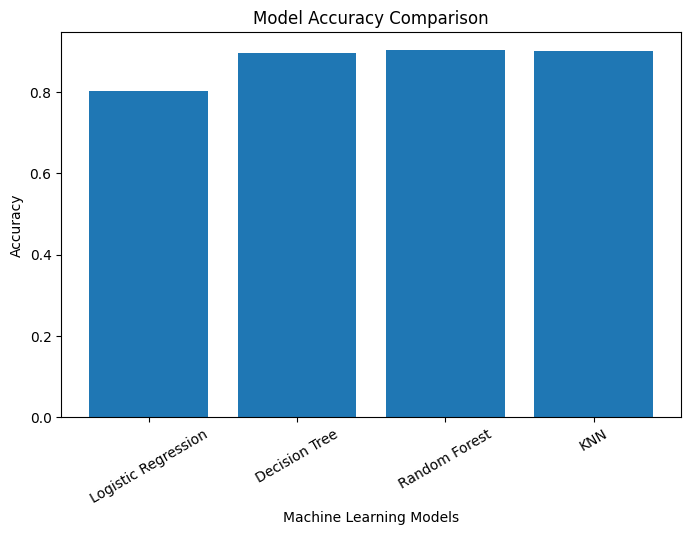

In [99]:
# visualization
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.bar(result_df["Model"], result_df["Accuracy"])

plt.title("Model Accuracy Comparison")
plt.ylabel("Accuracy")
plt.xlabel("Machine Learning Models")

plt.xticks(rotation=30)

plt.show()

# Implement Multi-class Logistic Regression

In [100]:
# train LR
sklearn_model = LogisticRegression(max_iter=1000)
lr_model.fit(X_train_m, y_train_m)


LogisticRegression(max_iter=1000)

In [101]:
# prediction
y_pred_lr_m = lr_model.predict(X_test_m)

In [102]:
# print accuracy
print("Accuracy:", accuracy_score(y_test_m, y_pred_lr_m))
print(classification_report(y_test_m, y_pred_lr_m))

Accuracy: 0.7534716873170625


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


              precision    recall  f1-score   support

      benign       0.75      0.99      0.86     27361
  bruteforce       0.00      0.00      0.00       374
        ddos       0.79      0.59      0.67      3611
         dos       0.78      0.73      0.76      3684
     malware       0.88      0.50      0.64      1508
        mitm       0.57      0.18      0.27      1612
       recon       0.65      0.18      0.29      6730
         web       0.00      0.00      0.00       559

    accuracy                           0.75     45439
   macro avg       0.55      0.40      0.44     45439
weighted avg       0.73      0.75      0.70     45439



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [103]:
# save lr_multi accuracy
lr_multi_accuracy = accuracy_score(y_test_m, y_pred_lr_m)
print(lr_multi_accuracy)

0.7534716873170625


# Implement Multi-class DT

In [104]:
# train DT
dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train_m, y_train_m)

DecisionTreeClassifier(random_state=42)

In [105]:
# prediction
y_pred_dt_m = dt_model.predict(X_test_m)

In [106]:
# print result
print("Accuracy:", accuracy_score(y_test_m, y_pred_dt_m))
print(classification_report(y_test_m, y_pred_dt_m))

Accuracy: 0.8831840489447391
              precision    recall  f1-score   support

      benign       0.89      0.95      0.92     27361
  bruteforce       0.57      0.45      0.50       374
        ddos       0.92      0.85      0.88      3611
         dos       0.94      0.91      0.93      3684
     malware       0.83      0.78      0.80      1508
        mitm       0.71      0.67      0.69      1612
       recon       0.87      0.71      0.78      6730
         web       0.98      0.82      0.89       559

    accuracy                           0.88     45439
   macro avg       0.84      0.77      0.80     45439
weighted avg       0.88      0.88      0.88     45439



In [107]:
#confusion matrix
confusion_matrix(y_test_m, y_pred_dt_m)

array([[26035,    50,   152,    87,   129,   300,   601,     7],
       [  136,   167,     2,     4,    22,    27,    16,     0],
       [  433,     3,  3073,    54,     4,    31,    13,     0],
       [  220,     5,    58,  3352,     6,    20,    23,     0],
       [  211,    27,     6,     5,  1179,    24,    56,     0],
       [  389,    31,    26,    25,    31,  1076,    34,     0],
       [ 1791,     9,    21,    24,    52,    41,  4788,     4],
       [   87,     3,     1,     0,     3,     1,     3,   461]])

In [108]:
# save
dt_multi_accuracy = accuracy_score(y_test_m, y_pred_dt_m)
print(dt_multi_accuracy)

0.8831840489447391


# Implement Random Forest for Multi-class

In [109]:
# random forest
rf_multi = RandomForestClassifier(n_estimators=100, random_state=42)

rf_multi.fit(X_train_m, y_train_m)

y_pred_rf_m = rf_multi.predict(X_test_m)

print("Accuracy:", accuracy_score(y_test_m, y_pred_rf_m))
print(classification_report(y_test_m, y_pred_rf_m))

Accuracy: 0.8918990294680781
              precision    recall  f1-score   support

      benign       0.89      0.96      0.92     27361
  bruteforce       0.70      0.46      0.55       374
        ddos       0.94      0.85      0.89      3611
         dos       0.96      0.92      0.94      3684
     malware       0.85      0.81      0.83      1508
        mitm       0.77      0.68      0.72      1612
       recon       0.89      0.71      0.79      6730
         web       0.98      0.84      0.91       559

    accuracy                           0.89     45439
   macro avg       0.87      0.78      0.82     45439
weighted avg       0.89      0.89      0.89     45439



In [110]:
# save
rf_multi_accuracy = accuracy_score(y_test_m, y_pred_rf_m)
print(rf_multi_accuracy)

0.8918990294680781


# KNN Implementation

In [111]:
# knn
knn_multi = KNeighborsClassifier(n_neighbors=5)

knn_multi.fit(X_train_m, y_train_m)

y_pred_knn_m = knn_multi.predict(X_test_m)

print("Accuracy:", accuracy_score(y_test_m, y_pred_knn_m))
print(classification_report(y_test_m, y_pred_knn_m))

Accuracy: 0.8838882897951099
              precision    recall  f1-score   support

      benign       0.87      0.98      0.92     27361
  bruteforce       0.39      0.26      0.31       374
        ddos       0.95      0.82      0.88      3611
         dos       0.96      0.89      0.92      3684
     malware       0.86      0.74      0.79      1508
        mitm       0.79      0.58      0.67      1612
       recon       0.92      0.66      0.77      6730
         web       0.95      0.79      0.86       559

    accuracy                           0.88     45439
   macro avg       0.84      0.72      0.77     45439
weighted avg       0.89      0.88      0.88     45439



In [112]:
#save
knn_multi_accuracy = accuracy_score(y_test_m, y_pred_knn_m)
print(knn_multi_accuracy)

0.8838882897951099


# SVM for multi-class

In [113]:
# from sklearn.svm import SVC

# svm_multi = SVC(kernel='rbf')

# svm_multi.fit(X_train_m, y_train_m)

# y_pred_svm_m = svm_multi.predict(X_test_m)

# print("Accuracy:", accuracy_score(y_test_m, y_pred_svm_m))
# print(classification_report(y_test_m, y_pred_svm_m))

In [114]:
# save
# svm_multi_accuracy = accuracy_score(y_test_m, y_pred_svm_m)
# print(svm_multi_accuracy)

In [115]:
results_multi = pd.DataFrame({
    "Model": ["Logistic Regression","Decision Tree","Random Forest","KNN"],
    "Accuracy":[lr_multi_accuracy, dt_multi_accuracy, rf_multi_accuracy, knn_multi_accuracy]
})

results_multi

,Model,Accuracy
0,Logistic Regression,0.753472
1,Decision Tree,0.883184
2,Random Forest,0.891899
3,KNN,0.883888


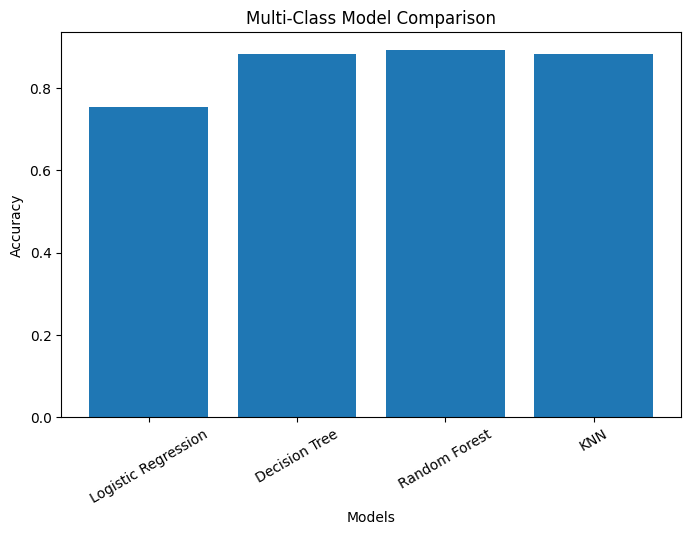

In [116]:
# plot diagram for model accuracy

import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.bar(results_multi["Model"], results_multi["Accuracy"])

plt.title("Multi-Class Model Comparison")
plt.ylabel("Accuracy")
plt.xlabel("Models")

plt.xticks(rotation=30)
plt.show()